In [1]:
# ============================================
# ЯЧЕЙКА 1: Импорты и настройка окружения
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import json
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

os.makedirs('artifacts/figures', exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Seed: {SEED}")

Using device: cpu
Seed: 42


=== Анализ данных ===
Размер: 4320
Диапазон: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски: 0


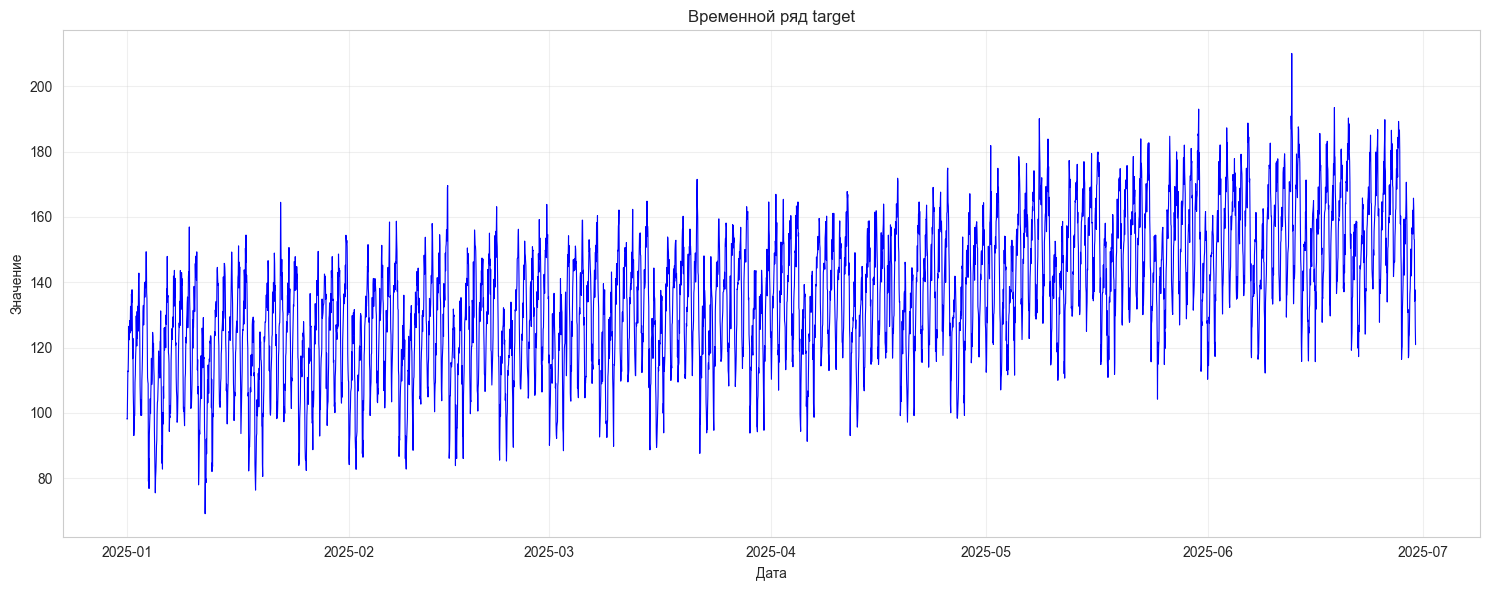

In [2]:
# ============================================
# ЯЧЕЙКА 2: Загрузка и первичный анализ данных
# ============================================

df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("=== Анализ данных ===")
print(f"Размер: {len(df)}")
print(f"Диапазон: {df['date'].min()} - {df['date'].max()}")
print(f"Пропуски: {df.isnull().sum().sum()}")

plt.figure(figsize=(15, 6))
plt.plot(df['date'], df['target'], linewidth=0.8, color='blue')
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/initial_series.png')
plt.show()

=== Temporal split ===
Train: 3456 строк
Validation: 432 строк
Test: 432 строк
Split summary: train=3456/val=432/test=432


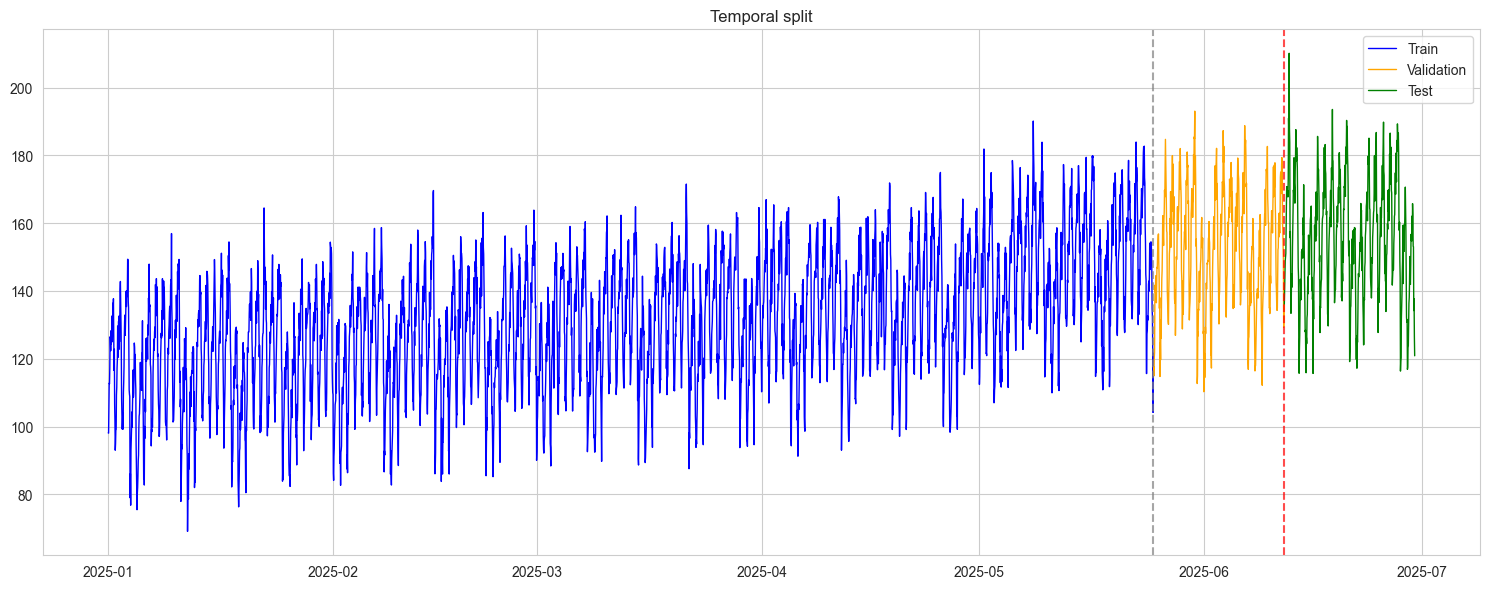


Почему random split некорректен:
- Нарушает временную структуру
- Создаёт утечку данных из будущего
- Даёт нереалистичную оценку качества


In [3]:
# ============================================
# ЯЧЕЙКА 3: Temporal split (без random shuffle)
# ============================================

n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("=== Temporal split ===")
print(f"Train: {len(train_df)} строк")
print(f"Validation: {len(val_df)} строк")
print(f"Test: {len(test_df)} строк")
print(f"Split summary: train={len(train_df)}/val={len(val_df)}/test={len(test_df)}")

plt.figure(figsize=(15, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', linewidth=1, color='blue')
plt.plot(val_df['date'], val_df['target'], label='Validation', linewidth=1, color='orange')
plt.plot(test_df['date'], test_df['target'], label='Test', linewidth=1, color='green')
plt.axvline(x=train_df['date'].iloc[-1], color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=val_df['date'].iloc[-1], color='red', linestyle='--', alpha=0.7)
plt.legend()
plt.title('Temporal split')
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png')
plt.show()

print("\nПочему random split некорректен:")
print("- Нарушает временную структуру")
print("- Создаёт утечку данных из будущего")
print("- Даёт нереалистичную оценку качества")

In [4]:
# ============================================
# ЯЧЕЙКА 4: Функции для признаков и метрик
# ============================================

def create_features(df, window_sizes=[7, 14]):
    df = df.copy()
    df = df.sort_values('date').reset_index(drop=True)
    
    # Лаговые признаки
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    
    # Rolling-признаки (с shift(1) для предотвращения утечки)
    for w in window_sizes:
        df[f'rolling_mean_{w}'] = df['target'].shift(1).rolling(window=w, min_periods=1).mean()
        df[f'rolling_std_{w}'] = df['target'].shift(1).rolling(window=w, min_periods=1).std().fillna(0)
    
    # Календарные признаки
    df['hour'] = df['date'].dt.hour
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    return df

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = np.abs(y_true) > 1e-6
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print("Функции загружены")
print("Созданы признаки: rolling_mean_7, rolling_std_7")

Функции загружены
Созданы признаки: rolling_mean_7, rolling_std_7


In [5]:
# ============================================
# ЯЧЕЙКА 5: Создание признаков
# ============================================

train_feat = create_features(train_df)
val_feat = create_features(val_df)
test_feat = create_features(test_df)

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
                'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'day_of_month', 'month']

train_feat = train_feat.dropna().reset_index(drop=True)
val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

X_train, y_train = train_feat[feature_cols], train_feat['target']
X_val, y_val = val_feat[feature_cols], val_feat['target']
X_test, y_test = test_feat[feature_cols], test_feat['target']

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"Признаки: {feature_cols}")
print("Проверка наличия rolling_mean_7:", 'rolling_mean_7' in X_train.columns)
print("Проверка наличия rolling_std_7:", 'rolling_std_7' in X_train.columns)

Train: 3442, Val: 418, Test: 418
Признаки: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'day_of_month', 'month']
Проверка наличия rolling_mean_7: True
Проверка наличия rolling_std_7: True


=== B1: Naive baseline ===
MAE: 6.2550, RMSE: 7.9303, MAPE: 4.16%


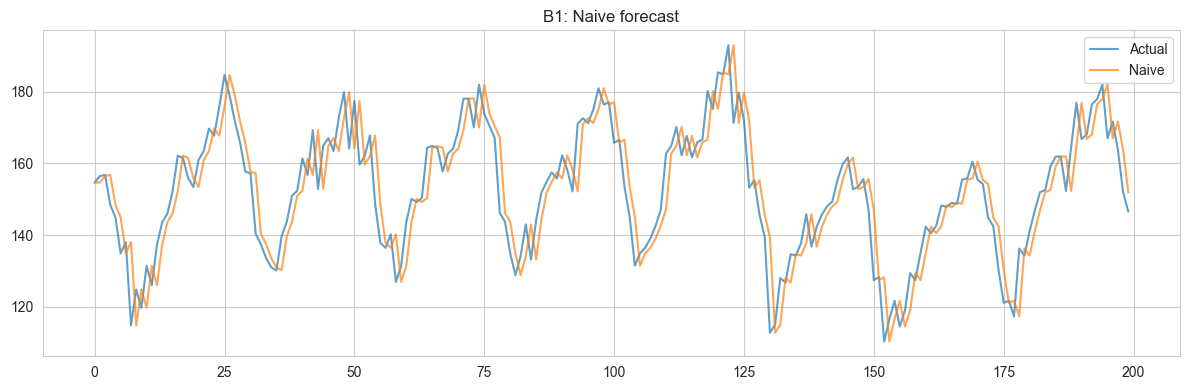

In [6]:
# ============================================
# ЯЧЕЙКА 6: B1 - Naive baseline
# ============================================

def naive_forecast(y_series):
    shifted = y_series.shift(1)
    return shifted.fillna(y_series.iloc[0])

y_pred_b1 = naive_forecast(val_feat['target'])
b1_metrics = evaluate_model(y_val, y_pred_b1)

print("=== B1: Naive baseline ===")
print(f"MAE: {b1_metrics['MAE']:.4f}, RMSE: {b1_metrics['RMSE']:.4f}, MAPE: {b1_metrics['MAPE']:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(y_val.values[:200], label='Actual', alpha=0.7)
plt.plot(y_pred_b1.values[:200], label='Naive', alpha=0.7)
plt.legend()
plt.title('B1: Naive forecast')
plt.tight_layout()
plt.savefig('artifacts/figures/b1_forecast.png')
plt.show()

=== B2: Moving Average ===
MAE: 13.3832, RMSE: 16.1392, MAPE: 8.99%


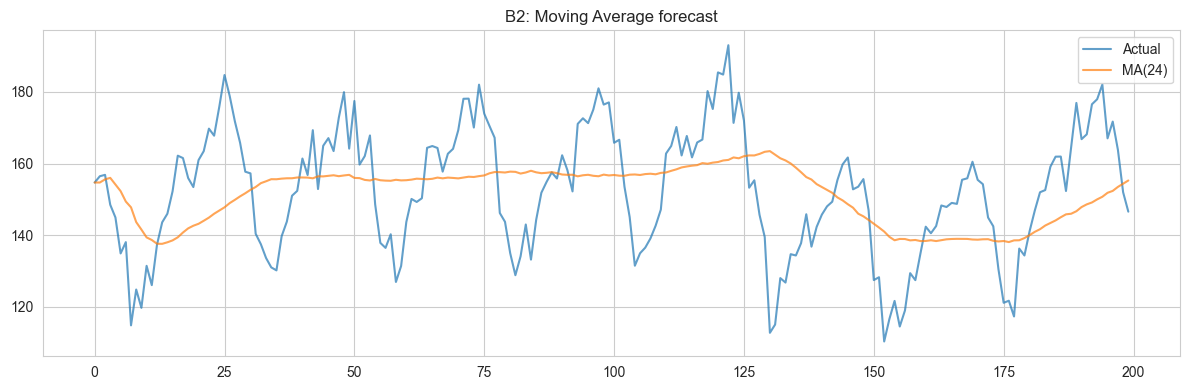

In [7]:
# ============================================
# ЯЧЕЙКА 7: B2 - Moving Average
# ============================================

def moving_average_forecast(y_series, window=24):
    shifted = y_series.shift(1)
    ma = shifted.rolling(window=window, min_periods=1).mean()
    return ma.fillna(y_series.iloc[0])

WINDOW_MA = 24
y_pred_b2 = moving_average_forecast(val_feat['target'], window=WINDOW_MA)
b2_metrics = evaluate_model(y_val, y_pred_b2)

print("=== B2: Moving Average ===")
print(f"MAE: {b2_metrics['MAE']:.4f}, RMSE: {b2_metrics['RMSE']:.4f}, MAPE: {b2_metrics['MAPE']:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(y_val.values[:200], label='Actual', alpha=0.7)
plt.plot(y_pred_b2.values[:200], label='MA(24)', alpha=0.7)
plt.legend()
plt.title('B2: Moving Average forecast')
plt.tight_layout()
plt.savefig('artifacts/figures/b2_forecast.png')
plt.show()

In [8]:
# ============================================
# ЯЧЕЙКА 8: B3 - Ridge regression (fit только на train)
# ============================================

scaler_ridge = StandardScaler()
X_train_scaled = scaler_ridge.fit_transform(X_train)
X_val_scaled = scaler_ridge.transform(X_val)
X_test_scaled = scaler_ridge.transform(X_test)

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_scaled, y_train)
y_pred_b3 = ridge.predict(X_val_scaled)
b3_metrics = evaluate_model(y_val, y_pred_b3)

print("=== B3: Ridge regression ===")
print(f"MAE: {b3_metrics['MAE']:.4f}, RMSE: {b3_metrics['RMSE']:.4f}, MAPE: {b3_metrics['MAPE']:.2f}%")

feat_imp = pd.DataFrame({'feature': feature_cols, 'coef': ridge.coef_}).sort_values('coef', key=abs, ascending=False)
print("\nВажность признаков (топ-5):")
print(feat_imp.head())

=== B3: Ridge regression ===
MAE: 5.2379, RMSE: 6.6371, MAPE: 3.44%

Важность признаков (топ-5):
     feature       coef
0      lag_1  13.860192
6   hour_cos  -4.462280
10     month   2.653980
5   hour_sin   1.717987
7    dow_sin   1.664652


In [9]:
# ============================================
# ЯЧЕЙКА 9: GRU классы
# ============================================

class TimeSeriesDataset(Dataset):
    def __init__(self, data, targets, window_size):
        self.data = data
        self.targets = targets
        self.window_size = window_size
    def __len__(self):
        return len(self.data) - self.window_size
    def __getitem__(self, idx):
        return (torch.FloatTensor(self.data[idx:idx + self.window_size]),
                torch.FloatTensor([self.targets[idx + self.window_size]]))

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

print("GRU классы загружены")

GRU классы загружены


In [10]:
# ============================================
# ЯЧЕЙКА 10: Подготовка GRU данных (fit scaler только на train)
# ============================================

WINDOW_SIZE = 24
BATCH_SIZE = 32
HIDDEN_DIM = 64
NUM_LAYERS = 2
EPOCHS = 100
LR = 0.001

scaler_gru = StandardScaler()
X_train_scaled_gru = scaler_gru.fit_transform(X_train)
X_val_scaled_gru = scaler_gru.transform(X_val)
X_test_scaled_gru = scaler_gru.transform(X_test)

train_dataset = TimeSeriesDataset(X_train_scaled_gru, y_train.values, WINDOW_SIZE)
val_dataset = TimeSeriesDataset(X_val_scaled_gru, y_val.values, WINDOW_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print("shuffle=False для сохранения временного порядка")

Train batches: 107, Val batches: 13
shuffle=False для сохранения временного порядка


=== Обучение GRU ===
Epoch 0: train_loss=15869.4158, val_loss=20633.3331
Epoch 20: train_loss=925.9464, val_loss=2294.9770
Epoch 40: train_loss=390.5609, val_loss=807.4372
Epoch 60: train_loss=392.7777, val_loss=779.3142
Epoch 80: train_loss=40.4321, val_loss=131.2927

Лучшая модель: эпоха 99, val_loss=52.0915


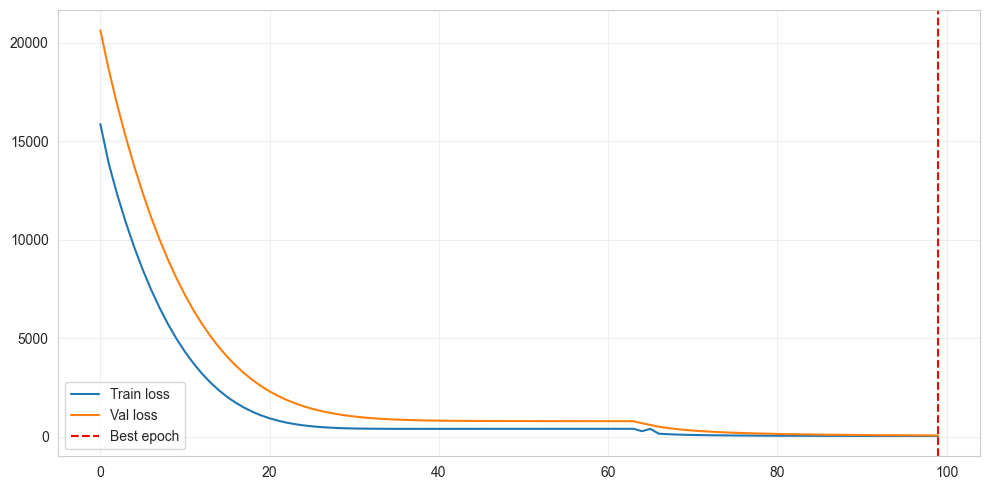

In [11]:
# ============================================
# ЯЧЕЙКА 11: Обучение GRU
# ============================================

model = GRUModel(len(feature_cols), HIDDEN_DIM, NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val_loss = float('inf')
best_epoch = 0

print("=== Обучение GRU ===")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_loss += criterion(model(X_batch), y_batch).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

print(f"\nЛучшая модель: эпоха {best_epoch}, val_loss={best_val_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.axvline(best_epoch, color='red', linestyle='--', label='Best epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

=== R1: GRU Forecast ===
MAE: 5.3556, RMSE: 7.1453, MAPE: 3.41%


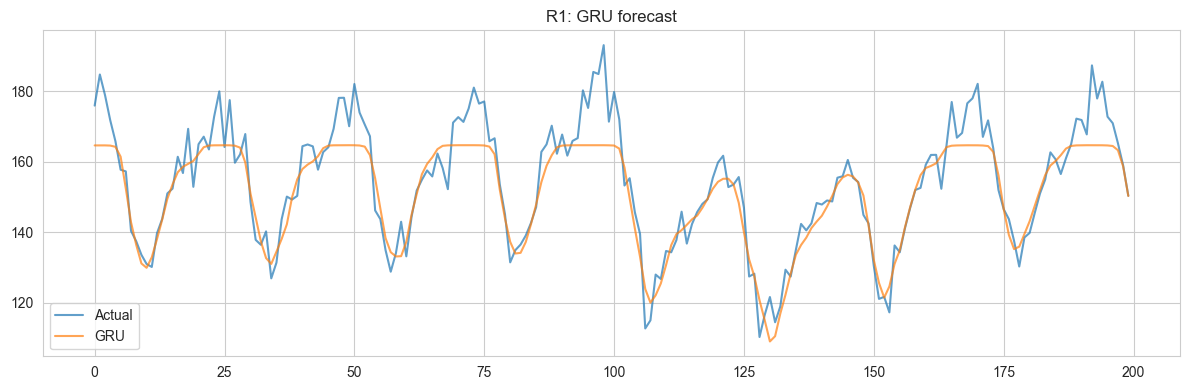

In [12]:
# ============================================
# ЯЧЕЙКА 12: Оценка GRU на validation
# ============================================

model.load_state_dict(torch.load('artifacts/best_gru.pt'))
model.eval()

y_pred_gru = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        y_pred_gru.extend(model(X_batch.to(device)).cpu().numpy().flatten())

y_pred_gru = np.array(y_pred_gru)
y_val_aligned = y_val.values[WINDOW_SIZE:]

r1_metrics = evaluate_model(y_val_aligned, y_pred_gru)

print("=== R1: GRU Forecast ===")
print(f"MAE: {r1_metrics['MAE']:.4f}, RMSE: {r1_metrics['RMSE']:.4f}, MAPE: {r1_metrics['MAPE']:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(y_val_aligned[:200], label='Actual', alpha=0.7)
plt.plot(y_pred_gru[:200], label='GRU', alpha=0.7)
plt.legend()
plt.title('R1: GRU forecast')
plt.tight_layout()
plt.savefig('artifacts/figures/r1_forecast.png')
plt.show()

In [13]:
# ============================================
# ЯЧЕЙКА 13: Сохранение результатов в runs.csv (с полными колонками)
# ============================================

split_summary = f"train={len(train_df)}/val={len(val_df)}/test={len(test_df)}"

results = pd.DataFrame([
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': split_summary,
        'window_size': None,
        'horizon': 1,
        'model_summary': 'naive-last',
        'features_summary': 'none',
        'scaler': 'none',
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': b1_metrics['MAE'],
        'best_val_rmse': b1_metrics['RMSE'],
        'best_val_mape': b1_metrics['MAPE'],
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'прогноз = последнее известное значение'
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': split_summary,
        'window_size': WINDOW_MA,
        'horizon': 1,
        'model_summary': 'moving-average',
        'features_summary': 'none',
        'scaler': 'none',
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': b2_metrics['MAE'],
        'best_val_rmse': b2_metrics['RMSE'],
        'best_val_mape': b2_metrics['MAPE'],
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': f'скользящее среднее с окном={WINDOW_MA}'
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': split_summary,
        'window_size': None,
        'horizon': 1,
        'model_summary': f'Ridge(alpha=1.0)',
        'features_summary': f'{len(feature_cols)} features: lag_1,7,14, rolling_mean_7, rolling_std_7, calendar',
        'scaler': 'StandardScaler',
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': b3_metrics['MAE'],
        'best_val_rmse': b3_metrics['RMSE'],
        'best_val_mape': b3_metrics['MAPE'],
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'Ridge на лаговых и календарных признаках'
    },
    {
        'experiment_id': 'R1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': split_summary,
        'window_size': WINDOW_SIZE,
        'horizon': 1,
        'model_summary': f'GRU({HIDDEN_DIM},{NUM_LAYERS})',
        'features_summary': f'{len(feature_cols)} features scaled',
        'scaler': 'StandardScaler',
        'optimizer': 'Adam',
        'lr': LR,
        'epochs_trained': best_epoch + 1,
        'best_val_mae': r1_metrics['MAE'],
        'best_val_rmse': r1_metrics['RMSE'],
        'best_val_mape': r1_metrics['MAPE'],
        'test_mae': None,
        'test_rmse': None,
        'test_mape': None,
        'notes': 'двухслойная GRU с dropout=0.2, оконное представление'
    }
])

results.to_csv('artifacts/runs.csv', index=False)
print("=== runs.csv сохранён ===")
print(results[['experiment_id', 'best_val_mae']])

=== runs.csv сохранён ===
  experiment_id  best_val_mae
0            B1      6.254976
1            B2     13.383244
2            B3      5.237879
3            R1      5.355641


In [14]:
# ============================================
# ЯЧЕЙКА 14: Сохранение конфига GRU (с масштабированием)
# ============================================

config = {
    'window_size': WINDOW_SIZE,
    'input_dim': len(feature_cols),
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'dropout': 0.2,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'epochs': EPOCHS,
    'best_epoch': best_epoch,
    'seed': SEED,
    'device': str(device),
    'scaler': {
        'type': 'StandardScaler',
        'mean': scaler_gru.mean_.tolist(),
        'scale': scaler_gru.scale_.tolist(),
        'feature_names': feature_cols
    },
    'normalization': {
        'method': 'StandardScaler',
        'fit_on': 'train_only',
        'description': 'Масштабирование выполнено на train, затем применено к val и test'
    }
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("=== best_gru_config.json сохранён ===")
print("Включены: scaler (mean, scale), normalization info")

=== best_gru_config.json сохранён ===
Включены: scaler (mean, scale), normalization info


=== Сравнение по val_MAE ===
B1 (Naive): 6.2550
B2 (MA): 13.3832
B3 (Ridge): 5.2379
R1 (GRU): 5.3556

Лучшая: B3 (Ridge) (MAE=5.2379)


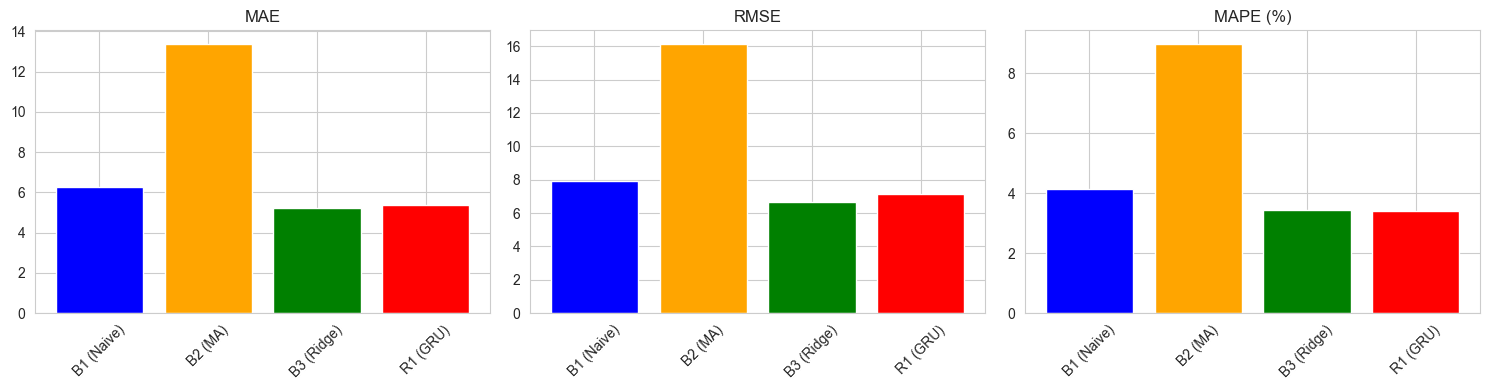

In [15]:
# ============================================
# ЯЧЕЙКА 15: Сравнение моделей
# ============================================

models = ['B1 (Naive)', 'B2 (MA)', 'B3 (Ridge)', 'R1 (GRU)']
mae_vals = [b1_metrics['MAE'], b2_metrics['MAE'], b3_metrics['MAE'], r1_metrics['MAE']]
rmse_vals = [b1_metrics['RMSE'], b2_metrics['RMSE'], b3_metrics['RMSE'], r1_metrics['RMSE']]
mape_vals = [b1_metrics['MAPE'], b2_metrics['MAPE'], b3_metrics['MAPE'], r1_metrics['MAPE']]

best_idx = np.argmin(mae_vals)
print("=== Сравнение по val_MAE ===")
for i, name in enumerate(models):
    print(f"{name}: {mae_vals[i]:.4f}")
print(f"\nЛучшая: {models[best_idx]} (MAE={mae_vals[best_idx]:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(models, mae_vals, color=['blue', 'orange', 'green', 'red'])
axes[0].set_title('MAE')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(models, rmse_vals, color=['blue', 'orange', 'green', 'red'])
axes[1].set_title('RMSE')
axes[1].tick_params(axis='x', rotation=45)
axes[2].bar(models, mape_vals, color=['blue', 'orange', 'green', 'red'])
axes[2].set_title('MAPE (%)')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

=== Финальная оценка B3 на test ===
MAE: 5.4227, RMSE: 6.9710, MAPE: 3.51%


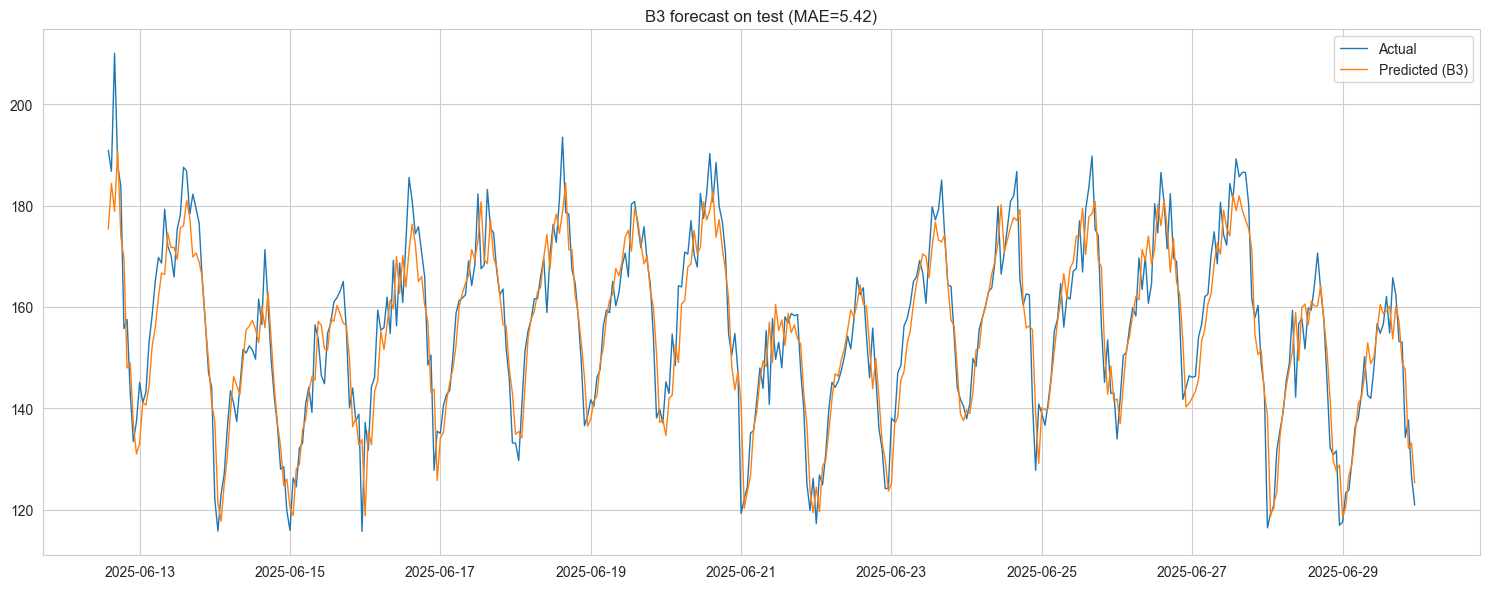


runs.csv обновлён


In [16]:
# ============================================
# ЯЧЕЙКА 16: Финальная оценка на test
# ============================================

best_model = models[best_idx].split()[0]

print(f"=== Финальная оценка {best_model} на test ===")

if best_model == 'R1':
    X_test_scaled = scaler_gru.transform(X_test)
    test_dataset = TimeSeriesDataset(X_test_scaled, y_test.values, WINDOW_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.load_state_dict(torch.load('artifacts/best_gru.pt'))
    model.eval()
    y_pred = []
    with torch.no_grad():
        for X_batch, _ in test_loader:
            y_pred.extend(model(X_batch.to(device)).cpu().numpy().flatten())
    y_pred = np.array(y_pred)
    y_true = y_test.values[WINDOW_SIZE:]
    dates = test_df['date'].iloc[WINDOW_SIZE:].values
    test_metrics = evaluate_model(y_true, y_pred)

elif best_model == 'B3':
    y_pred = ridge.predict(X_test_scaled)
    y_true = y_test.values
    dates = test_df['date'].iloc[14:].values
    test_metrics = evaluate_model(y_true, y_pred)

elif best_model == 'B2':
    y_pred = moving_average_forecast(test_feat['target'], window=WINDOW_MA).iloc[14:].values
    y_true = y_test.values
    dates = test_df['date'].iloc[14:].values
    test_metrics = evaluate_model(y_true, y_pred)

else:
    y_pred = naive_forecast(test_feat['target']).iloc[14:].values
    y_true = y_test.values
    dates = test_df['date'].iloc[14:].values
    test_metrics = evaluate_model(y_true, y_pred)

print(f"MAE: {test_metrics['MAE']:.4f}, RMSE: {test_metrics['RMSE']:.4f}, MAPE: {test_metrics['MAPE']:.2f}%")

plt.figure(figsize=(15, 6))
plt.plot(dates, y_true, label='Actual', linewidth=1)
plt.plot(dates, y_pred, label=f'Predicted ({best_model})', linewidth=1)
plt.legend()
plt.title(f'{best_model} forecast on test (MAE={test_metrics["MAE"]:.2f})')
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()

# Обновляем runs.csv с test метриками
df_results = pd.read_csv('artifacts/runs.csv')
df_results.loc[df_results['experiment_id'] == best_model, 'test_mae'] = test_metrics['MAE']
df_results.loc[df_results['experiment_id'] == best_model, 'test_rmse'] = test_metrics['RMSE']
df_results.loc[df_results['experiment_id'] == best_model, 'test_mape'] = test_metrics['MAPE']
df_results.to_csv('artifacts/runs.csv', index=False)
print("\nruns.csv обновлён")

In [17]:
# ============================================
# ЯЧЕЙКА 17: Итоговая информация
# ============================================

print("=" * 50)
print("HW12 ВЫПОЛНЕНА")
print("=" * 50)
print("\nАртефакты в папке artifacts/:")
print("- runs.csv (со всеми обязательными колонками)")
print("- best_gru.pt")
print("- best_gru_config.json (включает scaler и normalization)")
print("- figures/ (включая gru_learning_curves.png)")
print("\nОтчёт: report.md (с ссылкой на gru_learning_curves.png)")

HW12 ВЫПОЛНЕНА

Артефакты в папке artifacts/:
- runs.csv (со всеми обязательными колонками)
- best_gru.pt
- best_gru_config.json (включает scaler и normalization)
- figures/ (включая gru_learning_curves.png)

Отчёт: report.md (с ссылкой на gru_learning_curves.png)
